In [101]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
from sklearn.model_selection import train_test_split

In [102]:
from datasets import load_dataset

ds = load_dataset("asas-ai/ArCOV19-Rumors",'Tweets')

df = pd.DataFrame(ds["train"])

In [103]:
df = df[["tweetText", "label"]]
df["label"] = df["label"].map({True: 1, False: 0})

df.head()

,tweetText,label
0,قبل ظهور وباء #فيروس_كورونا، تنبأت بعض الأعمال...,0
1,قبل ظهور وباء #فيروس_كورونا، تنبأت بعض الأعمال...,0
2,قبل ظهور وباء #فيروس_كورونا، تنبأت بعض الأعمال...,0
3,فيديو| #أمريكا تتنبأ بـ«#كورونا» منذ 9 سنوات و...,0
4,تحدث عن الصين والخفافيش.. فيلم «كونتيجن» تنبأ ...,0


In [104]:
df.describe()

,label
count,3584.000000
mean,0.510882
std,0.499951
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [105]:
evd = pd.read_csv("AraFacts_cleaned.csv",sep=";")
evd = evd[["claim", "normalized_label"]]
evd["normalized_label"] = evd["normalized_label"].map({True: 1, False: 0})
evd.head()

,claim,normalized_label
0,فيديو يدعي أن: لقاح كورونا موجود حتى قبل بدأ ج...,0
1,لقاح كورونا يسبب عقم لدى النساء,0
2,ارتداء الكمامة يتسبب في زيادة مستويات ثاني أكس...,0
3,خسائر شركة رينو 8 مليار يورو بسبب المقاطعة,0
4,"""جامعة كاليفورنيا: فيروس كورونا يقتل نفسه بالط...",0


In [106]:
evd.describe()

,normalized_label
count,476.000000
mean,0.075630
std,0.264684
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


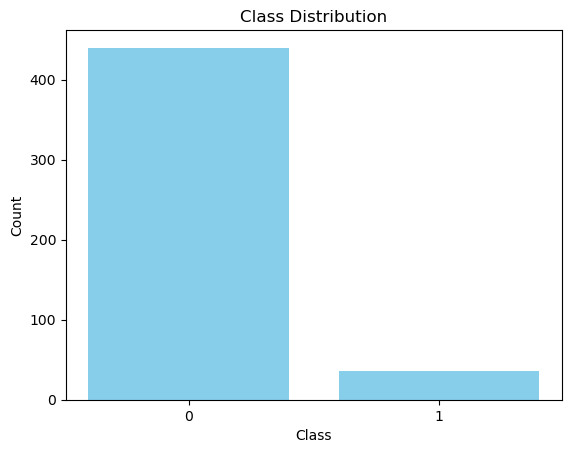

In [107]:
label_counts = evd["normalized_label"].value_counts()

plt.bar(label_counts.index, label_counts.values,color="skyblue")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks([0,1])
plt.show()

In [108]:
def clean_arabic(text):

    text = str(text)

    #remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # emove mentions
    text = re.sub(r"@\w+", "", text)

    #normalize arabic letters
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)

    #remove tashkeel
    text = re.sub(r"[\u0617-\u061A\u064B-\u0652]", "", text)

    #remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    #remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [109]:
df["clean_text"] = df["tweetText"].apply(clean_arabic)

evd["clean_claim"] = evd["claim"].apply(clean_arabic)

In [110]:
model = SentenceTransformer("Omartificial-Intelligence-Space/GATE-AraBert-v1")
print("model loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model loaded


In [111]:
X = model.encode(
    df["clean_text"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=False)
y = df["label"]

In [458]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y,test_size=0.3,random_state=26)

clf_normal = LogisticRegression(max_iter=200)

clf_normal.fit(X_train1, y_train1)

LogisticRegression(max_iter=200)

In [460]:
y_pred1 = clf_normal.predict(X_test1)

accuracy_lg_norm = accuracy_score(y_test1, y_pred1)
print(accuracy_lg_norm)

f1_lg_norm = f1_score(y_test1, y_pred1)
print(f1_lg_norm)

0.8996282527881041
0.9014598540145985


In [462]:
cm_norm = confusion_matrix(y_test1,y_pred1)
print(cm_norm)

tn, fp, fn, tp = cm_norm.ravel()
print("False Postive Rate: ",fp / (fp + tn))

[[474  48]
 [ 60 494]]
False Postive Rate:  0.09195402298850575


In [464]:
scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train1)
X_test_scaled1 = scaler.transform(X_test1)

svm_classifier_normal = SVC(kernel='linear', C=1.0)
svm_classifier_normal.fit(X_train_scaled1, y_train1)

y_pred2 = svm_classifier_normal.predict(X_test_scaled1)

accuracy_svm_norm = accuracy_score(y_test1, y_pred2)
print(accuracy_svm_norm )

f1_svm_norm  = f1_score(y_test1, y_pred2)
print(f1_svm_norm )

0.8847583643122676
0.8862385321100917


In [228]:
df_evd = df.copy()
X_evd = X.copy()

fake_evidence = evd[
    evd["normalized_label"] == 0]["clean_claim"].tolist()

real_evidence = evd[
    evd["normalized_label"] == 1]["clean_claim"].tolist()

#remove dulicates
fake_evidence = list(set(fake_evidence))
real_evidence = list(set(real_evidence))

In [230]:
fake_embeddings = model.encode(
    fake_evidence,
    convert_to_numpy=True,
    show_progress_bar=False)

real_embeddings = model.encode(
    real_evidence,
    convert_to_numpy=True,
    show_progress_bar=False)

In [231]:
fake_sims = []
real_sims = []

for emb in X_evd:

    fake_sim = np.max(cosine_similarity([emb], fake_embeddings))

    real_sim = np.max(cosine_similarity([emb], real_embeddings))

    fake_sims.append(fake_sim)
    real_sims.append(real_sim)

df_evd["fake_sim"] = fake_sims
df_evd["real_sim"] = real_sims

In [466]:
X_sim = df_evd[["fake_sim", "real_sim"]].values

X_modified = np.hstack([X,X_sim])

X_train, X_test, y_train, y_test = train_test_split(X_modified, y,test_size=0.3,random_state=26)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [468]:
y_pred = clf.predict(X_test)

accuracy_lg = accuracy_score(y_test, y_pred)
print(accuracy_lg)

f1_lg = f1_score(y_test, y_pred)
print(f1_lg)

0.904275092936803
0.9059360730593607


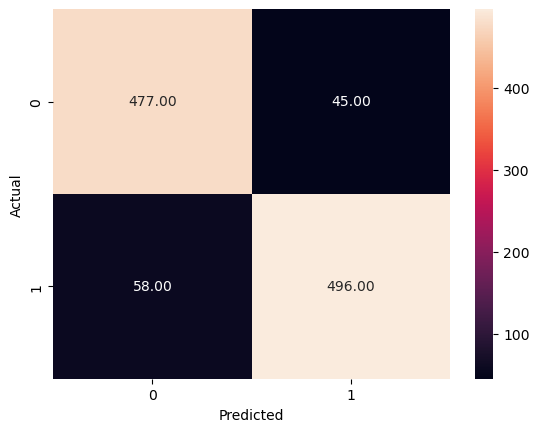

False Postive Rate:  0.08620689655172414


In [470]:
labels = ['0','1']
cm = confusion_matrix(y_test,y_pred)
df_cm = pd.DataFrame(cm, labels, labels)
sns.heatmap(df_cm,annot=True,fmt='.2f')
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Postive Rate: ",fp / (fp + tn))

In [448]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train_scaled , y_train)

y_pred = svm_classifier.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred)
print(accuracy_svm)

f1_svm = f1_score(y_test, y_pred)
print(f1_svm)

0.8921933085501859
0.8939670932358318


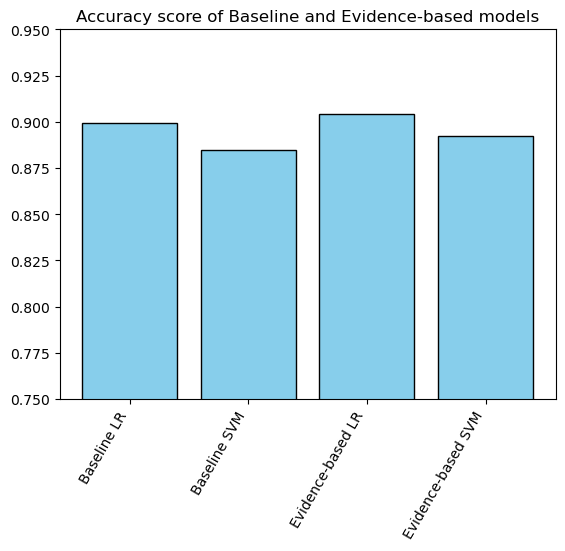

In [450]:
accuracy_list = [accuracy_lg_norm,accuracy_svm_norm,accuracy_lg,accuracy_svm]
accuracy_label = ["Baseline LR","Baseline SVM","Evidence-based LR","Evidence-based SVM"]

plt.bar(accuracy_label,accuracy_list,color="skyblue",edgecolor="black")
plt.xticks(rotation=60, ha='right')
plt.ylim(0.75, 0.95)
plt.title("Accuracy score of Baseline and Evidence-based models")
plt.show()